# Dados


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import multivariate_normal as mv_norm

from utils.data import generate_data
from utils.plot import plot_2D, plot_features

# Caminho relativo (funciona de qualquer lugar)
# data_path = Path("..") / "data" / "raw" / "gaussianas.csv"
# df = pd.read_csv(data_path)

# Estrutura do projeto

## Pipeline — Selective Classification

1. `data_generation(params)` → `X, y, g`

2. `get_posteriors(X, params)` → `posteriors` _(shape: N × K)_

3. `classifier(posteriors, confidence_fn)` → `y_hat, confidence`
   - `confidence_fn`: max_prob (default), margem, entropia, …

4. `selector(posteriors, g=None)` → `accept` _(shape: N, bool)_
   - threshold simples: usa `confidence` interna
   - plugin L2R (Narasimhan): usa `posteriors` + `g` diretamente
   - `.fit()` / `.predict()` — TODO: implementar

5. `metrics(y, y_hat, accept, g)` → `risk, ber, wg, coverage`
   - `risk`: risco total (com custo de rejeição)
   - `ber`: balanced error rate (sem custo de rejeição)
   - `wg`: weighted gain (com custo de rejeição)
   - `coverage`: proporção de amostras aceitas


# Funções auxiliares


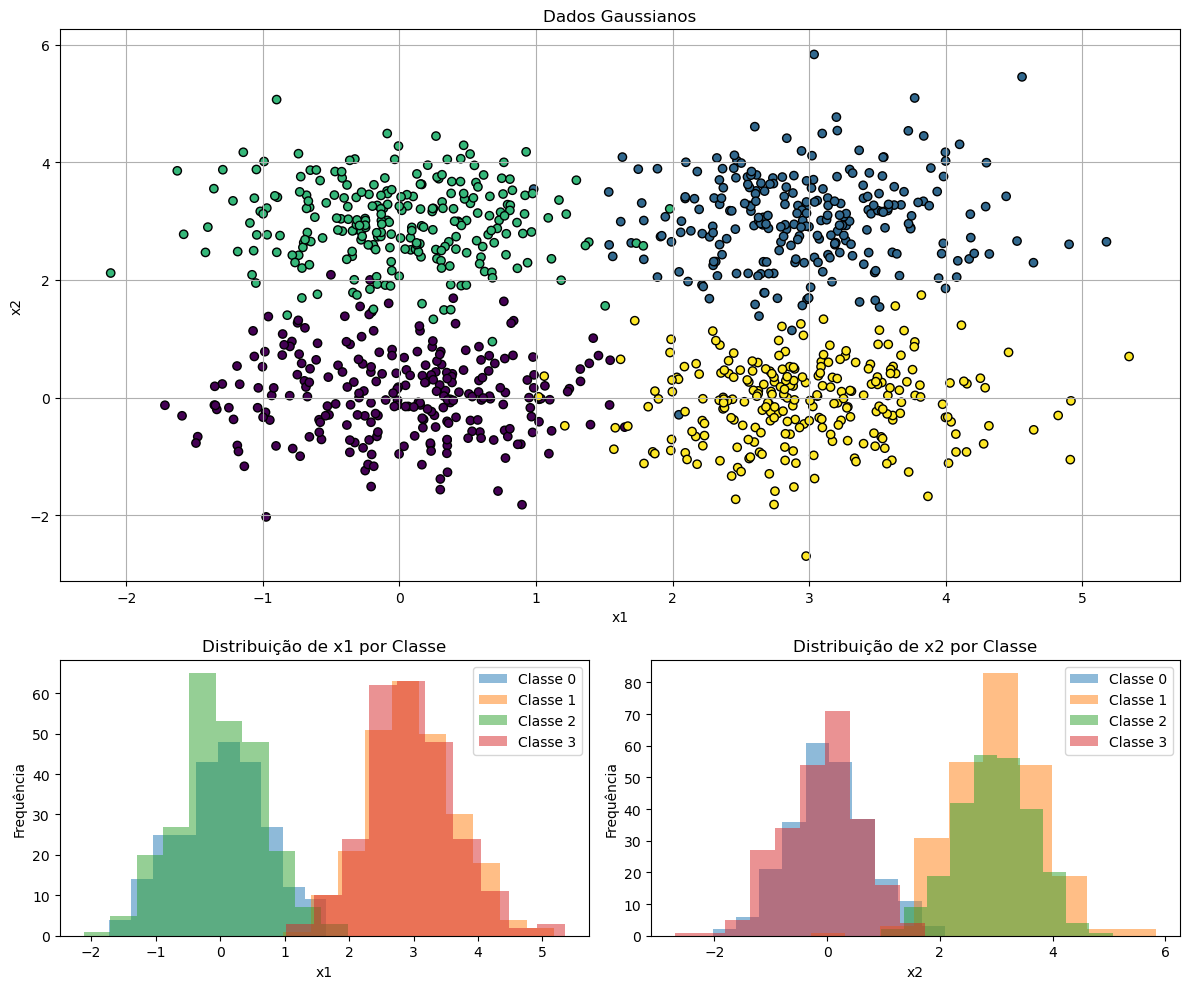

In [4]:
params = {
    "n_classes": 4,
    "n_samples": 1000,
    "means": [[0, 0], [3, 3], [0, 3], [3, 0]],
    "covs": [np.eye(2) * 0.5, np.eye(2) * 0.5, np.eye(2) * 0.5, np.eye(2) * 0.5],
    "priors": [0.25, 0.25, 0.25, 0.25],
    "seed": 42,
}


data, labels, groups = generate_data(**params)

plot_2D(data, labels)

In [5]:
def get_proba(data, **kwargs):
    means = kwargs["means"]
    covs = kwargs["covs"]
    priors = kwargs["priors"]
    n_classes = kwargs["n_classes"]

    prob = np.zeros((data.shape[0], n_classes))
    for i in range(n_classes):
        prob[:, i] = mv_norm(means[i], covs[i]).pdf(data)
        prob[:, i] *= priors[i]

    prob /= np.sum(prob, axis=1, keepdims=True)

    return prob

In [ ]:
def classifier(prob, **kwargs):
    confidence = np.max(prob, axis=1)
    pred = np.argmax(prob, axis=1)
    return pred, confidence


def rejector(confidence, threshold=None):
    mask = np.argsort(confidence)[::-1]
    if threshold is None:
        return mask
    accepted_indices = mask[confidence[mask] >= threshold]
    return accepted_indices

In [ ]:
def error(y, y_pred):
    accuracy = np.mean(y != y_pred)
    return accuracy


def balanced_error(y, y_pred):
    classes = np.unique(y)
    class_errors = []
    for cls in classes:
        cls_mask = y == cls
        cls_error = np.mean(y_pred[cls_mask] != cls)
        class_errors.append(cls_error)
    return np.mean(class_errors)


def worst_group_error(y, y_pred):
    unique_groups = np.unique(y)
    group_errors = []
    for group in unique_groups:
        group_mask = y == group
        group_error = np.mean(y_pred[group_mask] != y[group_mask])
        group_errors.append(group_error)
    return np.max(group_errors)

# Geração e predição


c:\Users\davis\miniconda3\envs\prob-ml\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\davis\miniconda3\envs\prob-ml\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


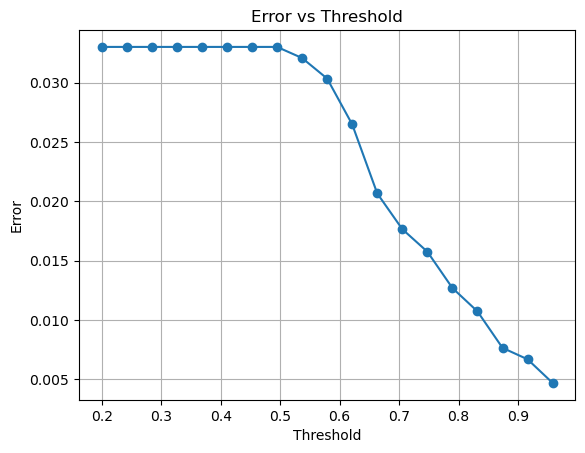

In [ ]:
params_1 = {
    "n_classes": 3,
    "means": [(-2, -2), (2, 2), (0, 0)],
    "covs": [[[0.5, 0], [0, 0.5]], [[0.5, 0], [0, 0.5]], [[0.5, 0], [0, 0.5]]],
    "priors": [0.3, 0.4, 0.3],
    "n_samples": 1000,
    "seed": 77,
}

data, labels, groups = generate_data(**params_1)

prob = get_proba(data, **params_1)

pred, confidence = classifier(prob)

mask = rejector(confidence, threshold=0)

# plot RC curve
thresholds = np.linspace(0.2, 1, 20)

errors = []
for threshold in thresholds:
    mask = rejector(confidence, threshold)
    y_pred_masked = pred[mask]
    y_true_masked = labels[mask]
    acc = error(y_true_masked, y_pred_masked)
    errors.append(acc)

plt.plot(thresholds, errors, marker="o")
plt.xlabel("Threshold")
plt.ylabel("Error")
plt.title("Error vs Threshold")
plt.grid()
plt.show()

# Curva de confiança


In [ ]:
# plot RC curve.

# rank de probabilidade, func de confiança
index = np.argsort(confidence)[::-1]
sorted_confidence = confidence[index]
sorted_labels = labels[index]
sorted_predictions = classifications[index]
sorted_errors = sorted_predictions != sorted_labels

# teste de argsort
# display(sorted_confidence[:5])
plt.plot(sorted_confidence[:100], marker="o")
plt.xlabel("Índice")
plt.ylabel("Confiança")
plt.show()

NameError: name 'confidence' is not defined

# Cobertura e prevalência


In [ ]:
coverages = np.linspace(0.2, 1, 10)

error_std = np.array([])
coberturas = np.array([])
bers = np.array([])
wgs = np.array([])
prevalence_1 = np.array([])
prevalence_2 = np.array([])


for k in coverages:
    # Cobertura
    index_k = int(k * len(sorted_labels))

    if (np.unique(sorted_labels[:index_k], return_counts=True)[1].min() > 5) & (
        len(np.unique(sorted_labels[:index_k])) == 2
    ):
        classes = np.unique(sorted_labels)

        # Selecionando os erros para a cobertura k
        errors_k = sorted_errors[:index_k]
        coberturas = np.append(coberturas, k)

        # error padrão da cobertura k
        error_rate_k = np.mean(errors_k)
        error_std = np.append(error_std, error_rate_k)

        # Erros por classe
        erros = [
            np.mean(sorted_errors[:index_k][sorted_labels[:index_k] == classe])
            for classe in classes
        ]

        # Erro Balanceado
        ber_k = np.mean(erros)
        bers = np.append(bers, ber_k)

        # Worst-group error
        wgs_k = np.max(erros)
        wgs = np.append(wgs, wgs_k)

        # Proporção das classes das classes
        prevalence_1 = np.append(
            prevalence_1, np.sum(sorted_labels[:index_k] == 0) / index_k
        )
        prevalence_2 = np.append(
            prevalence_2, np.sum(sorted_labels[:index_k] == 1) / index_k
        )

        assert np.isclose(
            prevalence_1[-1] + prevalence_2[-1], 1
        ), "A prevalência deve somar 1."

# AURC


In [ ]:
AURC_std = np.sum(error_std[1:] * np.diff(coberturas))
AURC_ber = np.sum(bers[1:] * np.diff(coberturas))
AURC_wgs = np.sum(wgs[1:] * np.diff(coberturas))

print(f"AURC (error padrão): {AURC_std:.4f}")
print(f"AURC (BER): {AURC_ber:.4f}")
print(f"AURC (WGS): {AURC_wgs:.4f}")

AURC (error padrão): 0.0151
AURC (BER): 0.0172
AURC (WGS): 0.0262


# Resultados


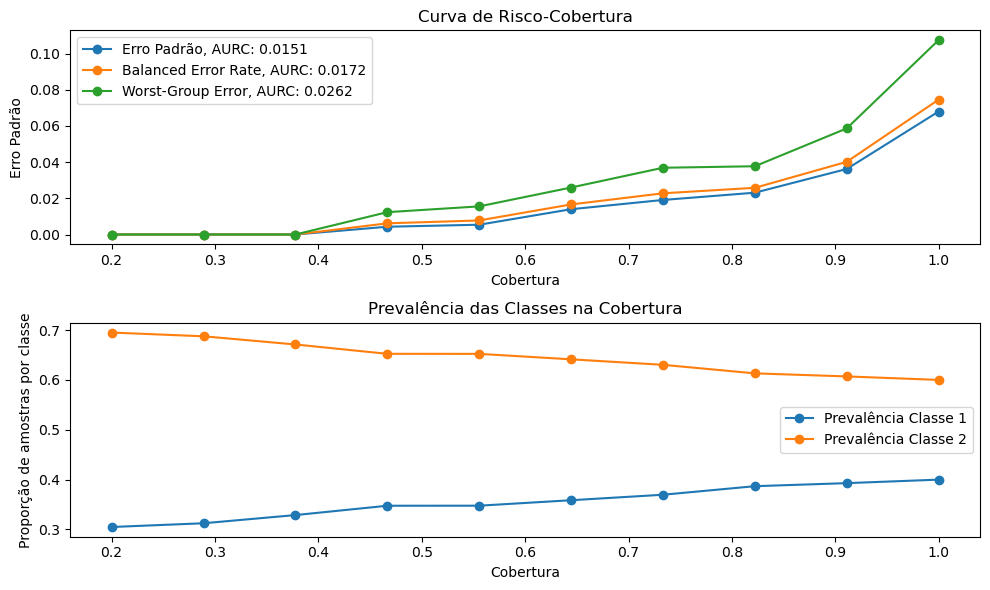

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].set_title("Curva de Risco-Cobertura")
axes[0].plot(
    coberturas,
    error_std,
    marker="o",
    label="Erro Padrão, AURC: {:.4f}".format(AURC_std),
)
axes[0].plot(
    coberturas,
    bers,
    marker="o",
    label="Balanced Error Rate, AURC: {:.4f}".format(AURC_ber),
)
axes[0].plot(
    coberturas,
    wgs,
    marker="o",
    label="Worst-Group Error, AURC: {:.4f}".format(AURC_wgs),
)
axes[0].set_xlabel("Cobertura")
axes[0].set_ylabel("Erro Padrão")
axes[0].legend()

axes[1].set_title("Prevalência das Classes na Cobertura")
axes[1].plot(coberturas, prevalence_1, marker="o", label="Prevalência Classe 1")
axes[1].plot(coberturas, prevalence_2, marker="o", label="Prevalência Classe 2")
axes[1].set_xlabel("Cobertura")
axes[1].set_ylabel("Proporção de amostras por classe")
axes[1].legend()

plt.tight_layout()
plt.show()